In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [2]:
raw = np.load("/content/PEMS08.npz")
data = raw["data"].astype(np.float32)

# Use traffic flow channel only
data = data[:, :, 0]   # (time, sensors)

SENSORS = data.shape[1]
print("Shape:", data.shape)

Shape: (17856, 170)


In [3]:
scaler = MinMaxScaler()
data = scaler.fit_transform(data)

In [4]:
corr = np.corrcoef(data.T)

k = 10
adj = np.zeros_like(corr)

for i in range(corr.shape[0]):
    idx = np.argsort(corr[i])[-k:]
    adj[i, idx] = 1

# Normalize adjacency
D = np.diag(1.0 / np.sqrt(adj.sum(axis=1) + 1e-6))
A = D @ adj @ D

A = torch.tensor(A, dtype=torch.float32)

In [5]:
SEQ_LEN = 96
PRED_LEN = 12

def create_sequences(data):
    X, Y = [], []
    for i in range(len(data) - SEQ_LEN - PRED_LEN):
        X.append(data[i:i+SEQ_LEN])
        Y.append(data[i+SEQ_LEN:i+SEQ_LEN+PRED_LEN])
    return np.array(X), np.array(Y)

X, Y = create_sequences(data)
print(X.shape, Y.shape)

(17748, 96, 170) (17748, 12, 170)


In [6]:
class TrafficDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X).float()
        self.Y = torch.tensor(Y).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

dataset = TrafficDataset(X, Y)

split = int(0.8 * len(dataset))
train_set = torch.utils.data.Subset(dataset, range(split))
val_set   = torch.utils.data.Subset(dataset, range(split, len(dataset)))

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=32)

In [7]:
class GraphConv(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, out_dim)

    def forward(self, x, A):
        # x: (B, T, N, F)
        x = torch.einsum("ij,btjf->btif", A, x)
        return self.linear(x)

In [8]:
class GNN_LLM_ADV(nn.Module):
    def __init__(self, sensors, pred_len):
        super().__init__()

        hidden = 64
        llm_dim = 128

        self.gcn1 = GraphConv(1, hidden)
        self.gcn2 = GraphConv(hidden, hidden)

        self.temporal = nn.Sequential(
            nn.Conv2d(hidden, hidden, (3,1), padding=(1,0)),
            nn.ReLU(),
            nn.Conv2d(hidden, hidden, (3,1), padding=(1,0)),
            nn.ReLU()
        )

        self.lstm = nn.LSTM(
            hidden,
            llm_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.2
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=llm_dim,
            nhead=8,
            dim_feedforward=256,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=3
        )

        self.fc = nn.Linear(llm_dim, sensors * pred_len)

        self.pred_len = pred_len
        self.sensors = sensors

    def forward(self, x, A):

        x = x.unsqueeze(-1)  # (B,T,N,1)

        x = torch.relu(self.gcn1(x, A))
        x = torch.relu(self.gcn2(x, A))

        B,T,N,F = x.shape
        x = x.permute(0,3,1,2)  # (B,F,T,N)

        x = self.temporal(x)

        x = x.permute(0,2,3,1)  # (B,T,N,F)

        x = x.mean(dim=2)  # spatial aggregation

        x,_ = self.lstm(x)

        x = self.transformer(x)

        x = x[:, -1, :]

        out = self.fc(x)

        return out.view(-1, self.pred_len, self.sensors)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GNN_LLM_ADV(SENSORS, PRED_LEN).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    patience=3,
    factor=0.5
)

loss_fn = nn.HuberLoss()
A = A.to(device)

In [10]:
best_val = 1e9
patience = 8
counter = 0

for epoch in range(60):

    model.train()
    train_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()

        pred = model(x, A)
        loss = loss_fn(pred, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            pred = model(x, A)
            val_loss += loss_fn(pred, y).item()

    val_loss /= len(val_loader)
    scheduler.step(val_loss)

    print(epoch, train_loss, val_loss)

    if val_loss < best_val:
        best_val = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pt")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break

0 0.017141865227614773 0.005359639816913284
1 0.004800081006062494 0.004552256690363425
2 0.004408011108066316 0.004396275023568992
3 0.004132424010832266 0.004157046897038985
4 0.003928166527305268 0.0038144967654040337
5 0.003724110184807901 0.0037879386684974772
6 0.003606392596617576 0.0038048513962568396
7 0.0034918071951733918 0.003685763238421599
8 0.003380936426257396 0.003418189371193482
9 0.0032966772376492553 0.0034651139830784486
10 0.003205973096506519 0.0033198149889489418
11 0.0031474360295252555 0.00341662296056244
12 0.0030890213412668992 0.003398192300763283
13 0.003015536964380157 0.003241070876053224
14 0.002965483037064792 0.0031096366038000597
15 0.002908735928285095 0.003174828831630818
16 0.00286355440720899 0.0032080440181055784
17 0.0028123425425718297 0.0032603056107119127
18 0.002773939116138478 0.002990728838847497
19 0.002686582404232861 0.003092388486120481
20 0.0025971413976491873 0.003011134913010808
21 0.002545218976101259 0.0029095017195465297
22 0.00

In [11]:
model.load_state_dict(torch.load("best_model.pt"))
model.eval()

preds, actual = [], []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        p = model(x, A).cpu().numpy()
        preds.append(p)
        actual.append(y.numpy())

preds = np.concatenate(preds)
actual = np.concatenate(actual)

preds_denorm = scaler.inverse_transform(
    preds.reshape(-1, preds.shape[-1])
).reshape(preds.shape)

actual_denorm = scaler.inverse_transform(
    actual.reshape(-1, actual.shape[-1])
).reshape(actual.shape)

mae  = np.mean(np.abs(preds_denorm - actual_denorm))
rmse = np.sqrt(np.mean((preds_denorm - actual_denorm)**2))

mask = actual_denorm > 10
mape = np.mean(
    np.abs((actual_denorm[mask] - preds_denorm[mask]) /
           actual_denorm[mask])
) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 21.775082
RMSE: 35.3084
MAPE: 12.405424


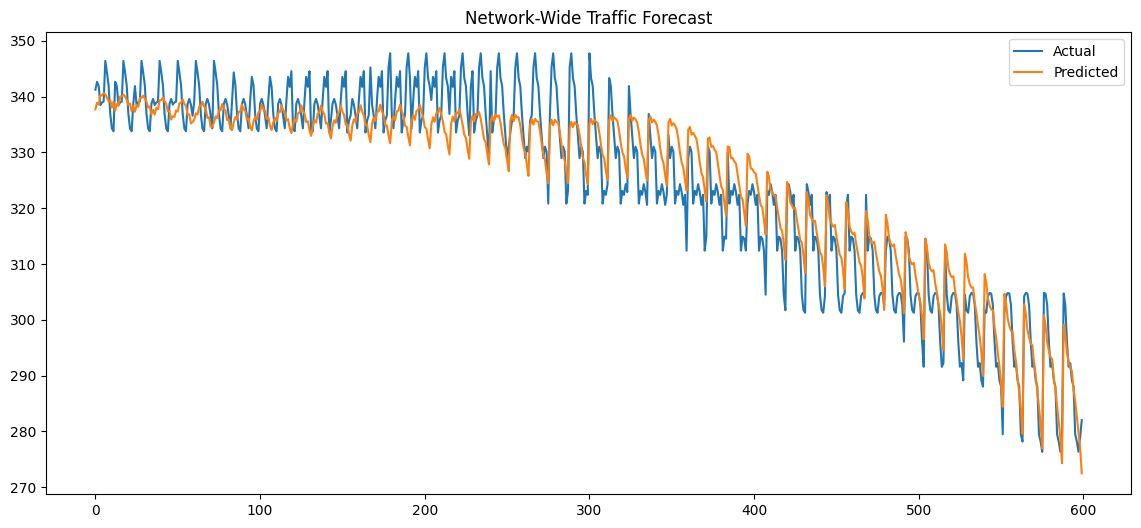

In [12]:
actual_mean = actual_denorm.mean(axis=2)
pred_mean   = preds_denorm.mean(axis=2)

plt.figure(figsize=(14,6))
plt.plot(actual_mean.reshape(-1)[:600], label="Actual")
plt.plot(pred_mean.reshape(-1)[:600], label="Predicted")
plt.legend()
plt.title("Network-Wide Traffic Forecast")
plt.show()